# Diabetes Prediction – Modeling

This notebook focuses on preparing the dataset for machine learning and building baseline models for diabetes prediction.

The steps include:
- Data loading
- Encoding categorical features
- Splitting dataset into training and testing sets
- Building baseline models for evaluation

## Importing Required Libraries

Basic Python libraries are imported to support data handling, numerical operations,
and visual exploration throughout the analysis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

sns.set_style("whitegrid")

## Loading the Dataset

The dataset is loaded using pandas to enable preprocessing and modelling.

In [2]:
df=pd.read_csv("../data/Dataset/diabetes_prediction_dataset-Copy1.csv")
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


## Preprocessing Step 1: Categorical Feature Inspection

Before encoding, categorical features are examined to understand their unique values.
This helps identify inconsistencies, unexpected categories, or irrelevant labels
that may affect model performance.

To avoid redundancy and multicollinearity, one category from each feature is dropped.

In [3]:
print("Gender Value Counts:\n")
print(df["gender"].value_counts())

print("\n---------------------------------\n")

print("Smoking History Value Counts:\n")
print(df["smoking_history"].value_counts())

Gender Value Counts:

gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64

---------------------------------

Smoking History Value Counts:

smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64


### Categorical Cleaning Decision:

- The 'Other' category in gender contains only 18 records (0.018% of data),
which is too small to contribute meaningful information. Therefore, it is removed.
- The smoking_history feature contains multiple categories, including ambiguous labels
such as 'No Info' and 'not current'. Since these categories represent a significant
portion of the dataset, they are retained to avoid data loss.

In [4]:
# Remove rare category
df = df[df["gender"] != "Other"]
df["gender"].value_counts()

gender
Female    58552
Male      41430
Name: count, dtype: int64

## Preprocessing Step 2: Feature and Target Separation

The dataset is divided into input features (X) and target variable (y).

The target variable is 'diabetes', which indicates whether a patient is diabetic (1) or not (0).
All other columns are treated as input features.

In [5]:
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

X shape: (99982, 8)
y shape: (99982,)
diabetes
0    91482
1     8500
Name: count, dtype: int64


## Preprocessing Step 3: Train-Test Split

The dataset is divided into training and testing sets to evaluate model performance.

Stratified sampling is used to preserve the class distribution of the target variable
in both training and testing sets. This is important due to the imbalance in the dataset.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (79985, 8)
X_test : (19997, 8)


In [7]:
# Checking stratification 
print("\nTrain distribution:\n", y_train.value_counts(normalize=True))
print("\nTest distribution:\n", y_test.value_counts(normalize=True))


Train distribution:
 diabetes
0    0.914984
1    0.085016
Name: proportion, dtype: float64

Test distribution:
 diabetes
0    0.914987
1    0.085013
Name: proportion, dtype: float64


## Preprocessing Step 4: Encoding & Scaling

To prepare the data for machine learning models, a preprocessing pipeline is created.

- Categorical features are encoded using OneHotEncoder
- Numerical features are scaled using StandardScaler
- ColumnTransformer is used to apply different transformations to different columns

This ensures a clean and consistent transformation process for both training and testing data.

In [8]:
categorical_cols = ["gender", "smoking_history"]

numerical_cols = [
    "age",
    "hypertension",
    "heart_disease",
    "bmi",
    "HbA1c_level",
    "blood_glucose_level"
]

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: ['gender', 'smoking_history']
Numerical: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']


In [9]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_transformer = OneHotEncoder(handle_unknown='ignore')
numerical_transformer = StandardScaler()

In [10]:
from sklearn.compose import ColumnTransformer

# preprocessor = ColumnTransformer(
#     transformers=[
#         ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
#     ], 
#     remainder='passthrough' # Keeps numerical columns as they are
# )

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_cols),
        ("num", numerical_transformer, numerical_cols)
    ]
)

## Baseline Model: Logistic Regression

A baseline model is built using Logistic Regression to establish initial performance.

The preprocessing pipeline (encoding + scaling) is combined with the model using
a unified pipeline. This ensures that all transformations are applied correctly
during training and testing without data leakage.

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
# Creting Model Pipeline
model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight='balanced'))
])

In [12]:
# Train Model
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [13]:
# Prediction
y_pred_lr = model.predict(X_test)

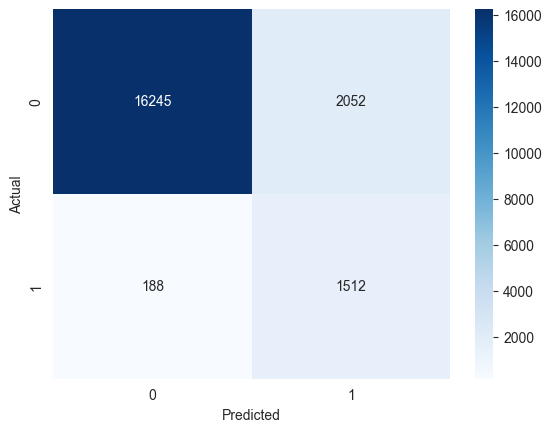



              precision    recall  f1-score   support

           0       0.99      0.89      0.94     18297
           1       0.42      0.89      0.57      1700

    accuracy                           0.89     19997
   macro avg       0.71      0.89      0.75     19997
weighted avg       0.94      0.89      0.90     19997



ROC-AUC Score: 0.9625931123392135


In [14]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Evaluation
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\n")
print(classification_report(y_test, y_pred_lr))
print("\n")
y_prob_lr =model.predict_proba(X_test)[:, 1]
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_lr))

## Remark:

The Logistic Regression model achieves high recall for diabetic cases,
indicating its effectiveness in identifying most positive instances.

However, the precision is relatively low, suggesting a higher number of false positives.
This trade-off is expected due to class imbalance handling using class weights.

While the model provides a good baseline, its linear nature limits its ability
to capture complex relationships in the data. Therefore, more advanced models
will be explored to improve overall performance.

---

## Ensemble Model: Voting Classifier

To leverage the strengths of multiple algorithms, a Voting Classifier is used.

Different models capture different patterns in the data:
- Logistic Regression captures linear relationships
- Random Forest handles non-linear interactions
- Gradient Boosting improves sequential learning
- Extra Trees Classifier finds optimal decision boundaries

A soft voting approach is used, where predictions are based on average probabilities.

---

In [15]:
# Import model
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, ExtraTreesClassifier

In [16]:
# Defining model
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
gb = GradientBoostingClassifier()
et = ExtraTreesClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)

In [17]:
# creting voting classifer model
voting_model = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('rf', rf),
        ('gb', gb),
        ("et", et)
    ],
    voting='soft',
    n_jobs=-1
)

In [18]:
# creating voting pipeline
voting_pipeline = Pipeline(
   steps=[
       ("preprocessing", preprocessor),
       ("classifier", voting_model)
   ],
   verbose=True
)

In [19]:
import time
# training
print("Starting Voting Classifier training...")
start_time = time.time()
voting_pipeline.fit(X_train, y_train)
end_time = time.time()
print("\nTraining completed.")
print(f"Total time taken: {end_time - start_time:.2f} seconds")

Starting Voting Classifier training...
[Pipeline] ..... (step 1 of 2) Processing preprocessing, total=   0.1s
[Pipeline] ........ (step 2 of 2) Processing classifier, total=  18.9s

Training completed.
Total time taken: 18.95 seconds


In [20]:
# Prediction
y_pred_voting = voting_pipeline.predict(X_test)

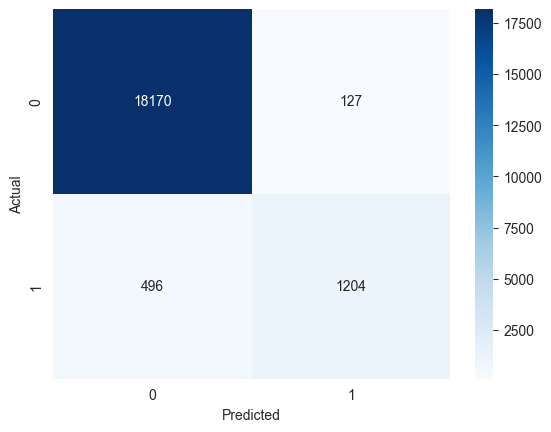



              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18297
           1       0.90      0.71      0.79      1700

    accuracy                           0.97     19997
   macro avg       0.94      0.85      0.89     19997
weighted avg       0.97      0.97      0.97     19997



ROC-AUC Score: 0.9729435072930632


In [21]:
# Evaluation
cm = confusion_matrix(y_test, y_pred_voting)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\n")
print(classification_report(y_test, y_pred_voting))
print("\n")
y_prob_voting = voting_pipeline.predict_proba(X_test)[:, 1]
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_voting))

## Remark:
The Voting Classifier significantly improves precision and F1-score compared to Logistic Regression,
indicating better overall balance in predictions.

While Logistic Regression achieves higher recall, it produces a large number of false positives.
In contrast, the Voting model reduces false positives substantially, leading to higher precision.

This demonstrates the effectiveness of ensemble learning in combining different model strengths
to achieve improved predictive performance.

---

## Ensemble Model: Random Forest Classifier

A Random Forest model is used as an improvement over Logistic Regression.

Random Forest is an ensemble of decision trees that can capture non-linear
relationships and interactions between features.

It also helps reduce overfitting by averaging multiple trees and can handle
imbalanced data using class weights.

In [22]:
# Defining model
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

In [23]:
# Creating pipeline
rf_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", rf)
])

In [24]:
print("Starting Random Forest Classifier training...")
start_time = time.time()
rf_pipeline.fit(X_train, y_train)
end_time = time.time()
print("\nTraining completed.")
print(f"Total time taken: {end_time - start_time:.2f} seconds")

Starting Random Forest Classifier training...

Training completed.
Total time taken: 1.62 seconds


In [25]:
# Prediction
y_pred_rf = rf_pipeline.predict(X_test)

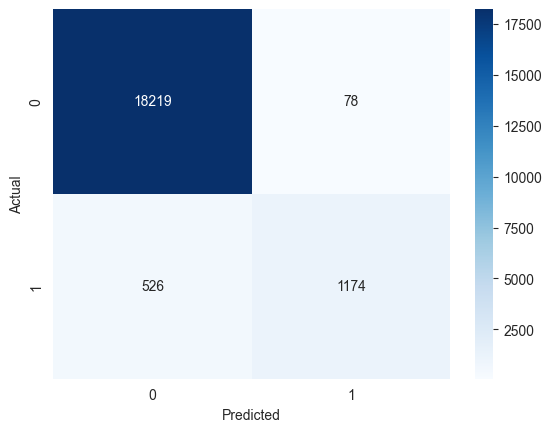



              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18297
           1       0.94      0.69      0.80      1700

    accuracy                           0.97     19997
   macro avg       0.95      0.84      0.89     19997
weighted avg       0.97      0.97      0.97     19997

ROC-AUC Score: 0.9639508405428083


In [26]:
# Evaluation
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\n")
print(classification_report(y_test, y_pred_rf))
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_rf))

## Remark:

The Random Forest model demonstrates strong predictive performance with high precision and overall accuracy.

Compared to Logistic Regression, Random Forest significantly improves precision and reduces false alarms.
However, compared to the Voting Classifier, it shows slightly lower recall, which may be a limitation in healthcare scenarios where identifying all positive cases is important.

Overall, Random Forest provides a robust and reliable model, but may require further tuning or comparison with advanced boosting methods for optimal performance.

---

## Ensembel Model: CatBoost

A CatBoost Classifier is implemented as the final model to capture complex
non-linear relationships in the data.

The model is configured with tuned hyperparameters and class weights to handle
class imbalance and improve F1-score.

CatBoost can handle categorical features internally without the need for
one-hot encoding or scaling.

Categorical columns are passed directly to the model using the `cat_features`
parameter, allowing CatBoost to apply its own encoding techniques.

In [27]:
from catboost import CatBoostClassifier
# defining model
cat = CatBoostClassifier(
    iterations=800,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='F1',
    class_weights=[1, 8],
    random_state=42,
    verbose=100
)

In [28]:
# get categorical column index
categorical_cols = ["gender", "smoking_history"]

cat_features = [X.columns.get_loc(col) for col in categorical_cols]

print(cat_features)

[0, 4]


In [29]:
# Training
print("Starting CatBoost Classifier training...")
start_time = time.time()
cat.fit(X_train, y_train, cat_features=cat_features)
end_time = time.time()
print("\nTraining completed.")
print(f"Total time taken: {end_time - start_time:.2f} seconds")

Starting CatBoost Classifier training...
0:	learn: 0.8744301	total: 217ms	remaining: 2m 53s
100:	learn: 0.9028623	total: 8.05s	remaining: 55.7s
200:	learn: 0.9045112	total: 14.4s	remaining: 42.9s
300:	learn: 0.9092277	total: 21.6s	remaining: 35.7s
400:	learn: 0.9133598	total: 28.9s	remaining: 28.8s
500:	learn: 0.9168147	total: 36.2s	remaining: 21.6s
600:	learn: 0.9196362	total: 43.6s	remaining: 14.4s
700:	learn: 0.9236142	total: 51s	remaining: 7.2s
799:	learn: 0.9263697	total: 58.3s	remaining: 0us

Training completed.
Total time taken: 58.66 seconds


In [30]:
# prediction
y_pred_cat = cat.predict(X_test)

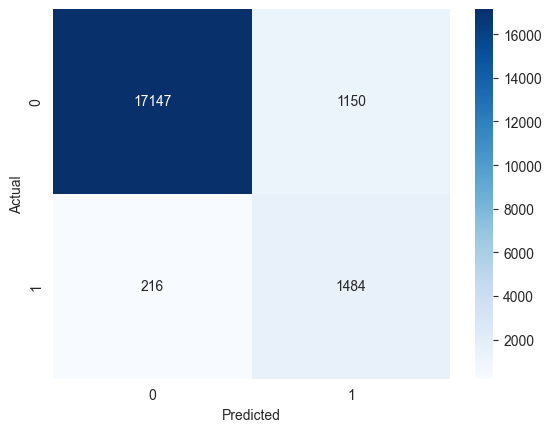



              precision    recall  f1-score   support

           0       0.99      0.94      0.96     18297
           1       0.56      0.87      0.68      1700

    accuracy                           0.93     19997
   macro avg       0.78      0.91      0.82     19997
weighted avg       0.95      0.93      0.94     19997

ROC-AUC Score: 0.9786958324894148


In [31]:
# Evaluation
cm = confusion_matrix(y_test, y_pred_cat)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\n")
print(classification_report(y_test, y_pred_cat))
y_prob_cat = cat.predict_proba(X_test)[:, 1]
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_cat))

## Remark:

The CatBoost model demonstrates strong performance in terms of recall and ROC-AUC score.

- The model achieves high recall for diabetic cases, indicating its effectiveness in identifying most positive instances.
- However, precision is relatively low, resulting in a higher number of false positives.
- The overall F1-score is lower compared to the Voting Classifier and Random Forest, indicating suboptimal balance.

Despite this, the ROC-AUC score is significantly high, suggesting that the model is capable of effectively distinguishing between classes based on predicted probabilities.

This indicates that the issue lies not in the model's learning capability, but in the default classification threshold (0.5). Since the dataset is imbalanced, the default threshold may not be optimal.

Therefore, threshold tuning is performed using predicted probabilities to achieve a better balance between precision and recall, with the goal of improving the overall F1-score.

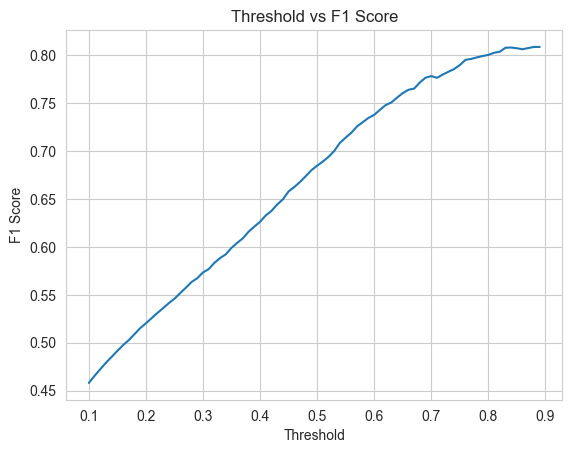

Best Threshold: 0.8899999999999996
Best F1: 0.808848945731075


In [32]:
from sklearn.metrics import f1_score

y_prob = cat.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)

best_threshold = 0
best_f1 = 0

f1_scores = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    f1 = f1_score(y_test, y_pred)
    f1_scores.append(f1)
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

plt.plot(thresholds, f1_scores)
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold vs F1 Score")
plt.show()

print("Best Threshold:", best_threshold)
print("Best F1:", best_f1)

## Threshold Optimization Remark:

The optimal threshold for maximizing F1-score was found to be approximately 0.89. However, this higher threshold makes the model more conservative, reducing false positives at the cost of potentially missing some positive cases (false negatives).

> From curve:  
Around 0.6–0.7  
F1 slightly lower (0.77–0.78)  
BUT recall will be higher
>  
> Around 0.89  
F1 highest (0.81)  
BUT recall will drop

In medical diagnosis scenarios such as diabetes prediction, recall is often prioritized to ensure that fewer positive cases are missed. Therefore, a slightly lower threshold (e.g., 0.7) may be preferred in practice to maintain a better balance between recall and precision.

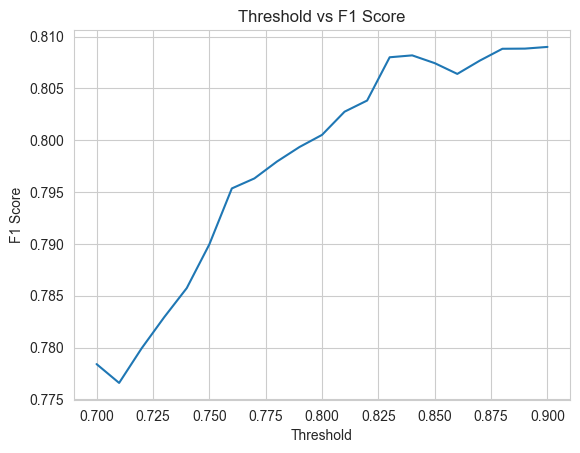

Best Threshold: 0.9000000000000001
Best F1: 0.8090121317157712


In [33]:
y_prob = cat.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.7, 0.9, 0.01)

best_threshold = 0
best_f1 = 0

f1_scores = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    f1 = f1_score(y_test, y_pred)
    f1_scores.append(f1)
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

plt.plot(thresholds, f1_scores)
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold vs F1 Score")
plt.show()

print("Best Threshold:", best_threshold)
print("Best F1:", best_f1)

In [34]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.7, 0.75, 0.8, 0.85, 0.9]

results = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append([t, precision, recall, f1])

df_results = pd.DataFrame(results, columns=["Threshold", "Precision", "Recall", "F1 Score"])

df_results

,Threshold,Precision,Recall,F1 Score
0,0.70,0.780935,0.775882,0.778401
1,0.75,0.835850,0.748824,0.789947
2,0.80,0.899486,0.721176,0.800522
3,0.85,0.950598,0.701765,0.807445
4,0.90,0.984810,0.686471,0.809012


## Final Threshold Selection (CatBoost)

Threshold tuning was performed to identify the optimal decision boundary for classification.

Although the highest F1-score (~0.81) occurs around threshold values between 0.85 and 0.90, a threshold of **0.85** is selected.

This choice ensures:
- High precision (reduced false positives)
- Acceptable recall (controlled false negatives)
- Stable performance across threshold range

Thus, threshold = 0.85 is used for final evaluation.

---

## Ensembel Mode: CatBoost (Tuned)

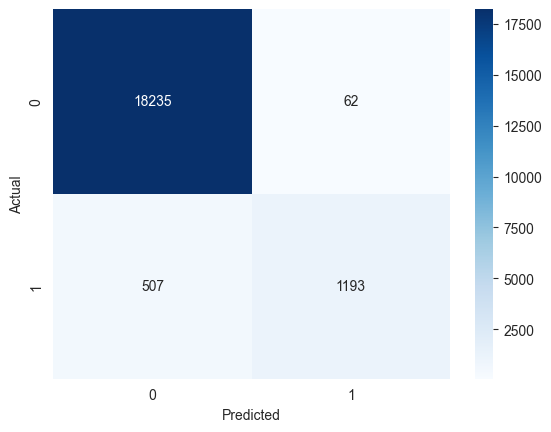



              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18297
           1       0.95      0.70      0.81      1700

    accuracy                           0.97     19997
   macro avg       0.96      0.85      0.90     19997
weighted avg       0.97      0.97      0.97     19997

ROC-AUC Score: 0.9786958324894148


In [39]:
# CatBoost (threshold = 0.85)
y_prob_cat = cat.predict_proba(X_test)[:, 1]
y_pred_cat_final = (y_prob_cat >= 0.85).astype(int)

cm_cat = confusion_matrix(y_test, y_pred_cat_final)

sns.heatmap(cm_cat, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\n")
print(classification_report(y_test, y_pred_cat_final))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_cat))

## Confusion Matrix Remark:

The confusion matrix shows:

- True Negatives are very high, indicating strong identification of non-diabetic cases.
- False Positives are very low, resulting in high precision.
- False Negatives exist, indicating that some diabetic cases are missed.

This reflects the trade-off introduced by threshold tuning:
- Increasing threshold reduces false positives
- But increases false negatives

Overall, the model maintains a balanced classification performance.

---

## Final Model Comparison Table

In [40]:
import pandas as pd

final_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Voting", "CatBoost", "CatBoost (Tuned)"],
    "Precision": [0.42, 0.94, 0.90, 0.56, 0.95],
    "Recall": [0.89, 0.69, 0.71, 0.87, 0.70],
    "F1 Score": [0.57, 0.80, 0.79, 0.68, 0.81],
    "ROC-AUC": [0.96, 0.96, 0.97, 0.97, 0.97]
}).round(3)

final_results

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.42,0.89,0.57,0.96
1,Random Forest,0.94,0.69,0.80,0.96
2,Voting,0.90,0.71,0.79,0.97
3,CatBoost,0.56,0.87,0.68,0.97
4,CatBoost (Tuned),0.95,0.70,0.81,0.97


## Model Comparison

- Logistic Regression achieves high recall but suffers from low precision.
- Random Forest improves precision but reduces recall.
- Voting Classifier balances both metrics effectively.
- CatBoost (after threshold tuning) achieves the highest F1-score.

This comparison shows that ensemble and boosting methods outperform linear models for this dataset.

---

## ROC Curve Comparison between CatBoost and Voting Classifier

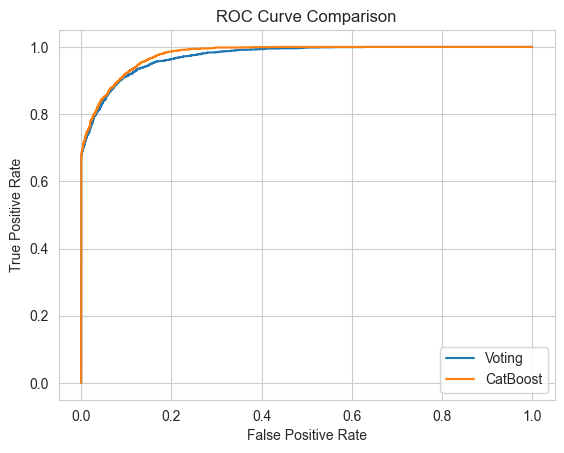

In [36]:
from sklearn.metrics import roc_curve

fpr_v, tpr_v, _ = roc_curve(y_test, y_prob_voting)
fpr_c, tpr_c, _ = roc_curve(y_test, y_prob_cat)

plt.plot(fpr_v, tpr_v, label="Voting")
plt.plot(fpr_c, tpr_c, label="CatBoost")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## ROC Curve Analysis

Both Voting and CatBoost models achieve high ROC-AUC scores (~0.97), indicating excellent class separability.

This means:
- The models can effectively distinguish between diabetic and non-diabetic cases
- Performance is strong across all classification thresholds

Since ROC-AUC is threshold-independent, it confirms that both models have strong underlying predictive capability.

---

## Feature Importance (CatBoost)

In [37]:
feature_importance = cat.get_feature_importance()
feature_names = X.columns

fi_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
}).sort_values(by="Importance", ascending=False)

fi_df

,Feature,Importance
6,HbA1c_level,44.357597
7,blood_glucose_level,37.591441
1,age,7.918253
5,bmi,5.928698
4,smoking_history,2.319493
0,gender,1.121014
2,hypertension,0.461054
3,heart_disease,0.302449


## Feature Importance Interpretation

The most important features include:

- Blood Glucose Level: Strongest indicator of diabetes
- HbA1c Level: Clinically significant measure of long-term glucose levels
- BMI: Reflects obesity, a known risk factor

These results align with medical knowledge, increasing confidence in the model's reliability.

---

## Cross-Validation of Voting Classifier:

In [43]:
scores = cross_val_score(voting_pipeline, X, y, cv=5, scoring='roc_auc')

print("Cross-Validation ROC-AUC Scores:", scores)
print("Mean ROC-AUC:", scores.mean())

[Pipeline] ..... (step 1 of 2) Processing preprocessing, total=   0.1s
[Pipeline] ........ (step 2 of 2) Processing classifier, total=  17.7s
[Pipeline] ..... (step 1 of 2) Processing preprocessing, total=   0.1s
[Pipeline] ........ (step 2 of 2) Processing classifier, total=  15.0s
[Pipeline] ..... (step 1 of 2) Processing preprocessing, total=   0.1s
[Pipeline] ........ (step 2 of 2) Processing classifier, total=  16.2s
[Pipeline] ..... (step 1 of 2) Processing preprocessing, total=   0.1s
[Pipeline] ........ (step 2 of 2) Processing classifier, total=  11.4s
[Pipeline] ..... (step 1 of 2) Processing preprocessing, total=   0.1s
[Pipeline] ........ (step 2 of 2) Processing classifier, total=  11.8s
Cross-Validation ROC-AUC Scores: [0.97247448 0.97307272 0.97042319 0.97298664 0.97319819]
Mean ROC-AUC: 0.9724310429136909


## Cross-Validation Interpretation:
The ROC-AUC scores obtained across 5 folds are: [0.972, 0.973, 0.970, 0.973, 0.973]  
The mean ROC-AUC score is approximately **0.972**.

- The ROC-AUC scores are consistently high across all folds, indicating strong model performance.
- The variation between folds is very small, demonstrating low variance.
- This suggests that the model is stable and not dependent on a specific train-test split.

Overall, the cross-validation results confirm that the model generalizes well to unseen data.

---

## Final Model Selection

Based on evaluation:

- CatBoost achieved the highest F1-score (~0.81)
- Maintained strong precision (0.95)
- Provided balanced performance after threshold tuning

Although the Voting Classifier showed competitive performance, CatBoost was selected because:
- It achieved slightly better results
- It is a single model (simpler deployment)
- It demonstrated stable behavior across thresholds

Therefore, **CatBoost with threshold = 0.85** is selected as the final model.

## Conclusion

This project developed a complete machine learning pipeline for diabetes prediction, including preprocessing, model training, evaluation, and optimization.

Multiple models were analyzed to understand trade-offs between precision and recall. Logistic Regression favored recall, while Random Forest improved precision. Ensemble learning through Voting provided balanced performance.

CatBoost demonstrated the best overall performance after threshold tuning, achieving the highest F1-score and strong precision. ROC analysis further confirmed the model’s ability to distinguish between classes effectively.

Threshold optimization played a key role in improving classification performance, especially in handling class imbalance.

However, the model is limited by the available features, as important medical factors such as family history and lifestyle were not included.

Future improvements may include:
- Incorporating additional medical features such as family history and lifestyle factors  
- Using larger and more diverse datasets  
- Exploring advanced ensemble techniques such as stacking for improved model combination  
- Investigating deep learning approaches such as Artificial Neural Networks (ANN), particularly if larger datasets with richer feature representations are available  